## Análisis univariable

### By:
Bryan Escobar Restrepo

### Date:
2026-08-21

### Description:

Primer notebook de la etapa de análisis (`3-analysis`). Parte del dataset ya tipado en
`2-exploration` (`data/02_intermediate/admisiones_type_fixed.parquet`, 471 x 8) y
estudia **cada atributo por separado**, siguiendo los pasos de
<https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/>.

Para cada variable se documenta:

- Nombre y tipo de dato (categórico ordinal / nominal, numérico entero o flotante,
  acotado o no, booleano, fecha).
- Porcentaje de valores nulos.
- Valores exactamente duplicados (filas y columnas).
- Ruido presente y de qué tipo (redondeo, atípicos, estocástico, errores de captura).
- Si es o no posiblemente útil para el proyecto.
- Descripción estadística: tendencia central (media, mediana, moda, mín, máx),
  dispersión (rango, IQR, cuartiles, varianza, desviación estándar, coeficiente de
  variación) y forma (*skewness*, *kurtosis*, tipo de distribución).

Y con eso se derivan las **reglas de validación de datos** que se usarán en las
siguientes etapas del proyecto.

**Los tres notebooks de `3-analysis`:** `03.1` univariable (este), `03.2` bivariable
(relaciones entre pares) y `03.3` multivariable (tres o más variables a la vez, más el
modelo heurístico).

## 📚 Import  libraries

In [1]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scipy
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)

print(f"pandas     {pd.__version__}")
print(f"seaborn    {sns.__version__}")
print(f"scipy      {scipy.__version__}")

pandas     3.0.5
seaborn    0.13.2
scipy      1.18.0


## ⚙️ Configuración

In [2]:
def buscar_raiz_proyecto() -> Path:
    """Sube por el árbol de directorios hasta encontrar la raíz del repositorio."""
    marcadores = (".git", "pyproject.toml")
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if any((candidato / marcador).exists() for marcador in marcadores):
            return candidato
    return actual


ARCHIVO_ENTRADA = (
    buscar_raiz_proyecto() / "data" / "02_intermediate" / "admisiones_type_fixed.parquet"
)

COLS_NUMERICAS = ["gre_score", "toefl_score", "sop", "lor", "cgpa"]
TARGET = "chance_of_admit"

sns.set_theme(style="whitegrid", palette="deep")
print(f"Entrada: {ARCHIVO_ENTRADA.relative_to(ARCHIVO_ENTRADA.parents[2])}")

Entrada: data/02_intermediate/admisiones_type_fixed.parquet


## 💾 Load data

Se carga el `.parquet` de `02_intermediate`, no el CSV crudo: ese archivo ya trae el
esquema resuelto, así que no hay que repetir ninguna conversión de tipos aquí.

In [3]:
df = pd.read_parquet(ARCHIVO_ENTRADA)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gre_score          460 non-null    Int64   
 1   toefl_score        452 non-null    Int64   
 2   university_rating  465 non-null    category
 3   sop                455 non-null    Float64 
 4   lor                463 non-null    Float64 
 5   cgpa               469 non-null    Float64 
 6   research           442 non-null    boolean 
 7   chance_of_admit    471 non-null    Float64 
dtypes: Float64(4), Int64(2), boolean(1), category(1)
memory usage: 26.4 KB


In [4]:
df.head()

,gre_score,toefl_score,university_rating,sop,lor,cgpa,research,chance_of_admit
0,337,118,4,4.5,4.5,9.65,True,0.92
1,324,107,4,4.0,4.5,8.87,True,0.76
2,316,104,3,3.0,3.5,8.0,True,0.72
3,322,110,3,3.5,2.5,8.67,True,0.8
4,314,103,2,2.0,3.0,8.21,False,0.65


## 📋 Ficha técnica por atributo

Inventario general antes de mirar cada variable en detalle: tipo de dato, porcentaje
de nulos, cardinalidad, y una valoración de ruido y utilidad para el proyecto
(predecir `chance_of_admit`). Las columnas `ruido` y `util_para_el_proyecto` son
juicios cualitativos; el resto sale de los datos.

In [5]:
TIPOS_DATO = {
    "gre_score": "numérica entera, acotada [0, 340]",
    "toefl_score": "numérica entera, acotada [0, 120]",
    "university_rating": "categórica ordinal, 5 niveles (1 < 2 < 3 < 4 < 5)",
    "sop": "numérica discreta (pasos de 0.5), acotada [1, 5] — escala ordinal",
    "lor": "numérica discreta (pasos de 0.5), acotada [1, 5] — escala ordinal",
    "cgpa": "numérica continua, acotada [0, 10]",
    "research": "booleana (0/1)",
    "chance_of_admit": "numérica continua, acotada [0, 1] — TARGET",
}

RUIDO = {
    "gre_score": "ninguno relevante; 0 valores fuera del dominio documentado",
    "toefl_score": "ninguno relevante; 0 valores fuera del dominio documentado",
    "university_rating": "ninguno; escala cerrada 1-5, sin valores invalidos",
    "sop": "redondeo a pasos de 0.5 (resolucion del instrumento, no error)",
    "lor": "redondeo a pasos de 0.5; 1 valor atipico segun IQR",
    "cgpa": "1 valor atipico segun IQR (6.8, el minimo observado)",
    "research": "ninguno; indicador binario limpio",
    "chance_of_admit": "2 valores en la cola baja fuera del IQR (0.34)",
}

UTILIDAD = {
    "gre_score": "si: segundo predictor individual mas fuerte (ver 03.2)",
    "toefl_score": "si: muy correlacionado con el target y con gre_score",
    "university_rating": "si: separa el promedio del target de forma monotona",
    "sop": "si, moderada: autoevaluacion subjetiva del aspirante",
    "lor": "si, moderada: evaluacion de terceros, redundante con sop",
    "cgpa": "si: el predictor individual mas correlacionado con el target",
    "research": "si: separa el target en dos grupos con medias distintas",
    "chance_of_admit": "es el target del proyecto, no un predictor",
}

ficha = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "tipo_de_dato": pd.Series(TIPOS_DATO),
        "n_nulos": df.isna().sum(),
        "%_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(),
        "ruido": pd.Series(RUIDO),
        "util_para_el_proyecto": pd.Series(UTILIDAD),
    }
)
ficha

,dtype,tipo_de_dato,n_nulos,%_nulos,n_unicos,ruido,util_para_el_proyecto
gre_score,Int64,"numérica entera, acotada [0, 340]",11,2.34,49,ninguno relevante; 0 valores fuera del dominio...,si: segundo predictor individual mas fuerte (v...
toefl_score,Int64,"numérica entera, acotada [0, 120]",19,4.03,29,ninguno relevante; 0 valores fuera del dominio...,si: muy correlacionado con el target y con gre...
university_rating,category,"categórica ordinal, 5 niveles (1 < 2 < 3 < 4 < 5)",6,1.27,5,"ninguno; escala cerrada 1-5, sin valores inval...",si: separa el promedio del target de forma mon...
sop,Float64,"numérica discreta (pasos de 0.5), acotada [1, ...",16,3.40,9,redondeo a pasos de 0.5 (resolucion del instru...,"si, moderada: autoevaluacion subjetiva del asp..."
lor,Float64,"numérica discreta (pasos de 0.5), acotada [1, ...",8,1.70,9,redondeo a pasos de 0.5; 1 valor atipico segun...,"si, moderada: evaluacion de terceros, redundan..."
cgpa,Float64,"numérica continua, acotada [0, 10]",2,0.42,168,"1 valor atipico segun IQR (6.8, el minimo obse...",si: el predictor individual mas correlacionado...
research,boolean,booleana (0/1),29,6.16,2,ninguno; indicador binario limpio,si: separa el target en dos grupos con medias ...
chance_of_admit,Float64,"numérica continua, acotada [0, 1] — TARGET",0,0.00,60,2 valores en la cola baja fuera del IQR (0.34),"es el target del proyecto, no un predictor"


**Sobre fechas y texto:** no hay ninguna columna de tipo fecha ni de texto libre en
este dataset. Cada fila es la fotografía del perfil de un aspirante, sin marca
temporal, así que no hay series de tiempo que analizar ni orden cronológico que
respetar al partir en *train*/*test* más adelante.

**Nulos:** ninguna columna supera el 6.2 %. La más incompleta es `research` (6.16 %) y
la variable objetivo no tiene ninguno, que es lo único crítico en esta etapa.

## 🎯 Variable objetivo (target): `chance_of_admit`

Se trata de un problema de **aprendizaje supervisado de regresión**: el target es
continuo en [0, 1], no una clase. Por eso no aplica el concepto de "clase
desbalanceada"; lo que importa es su forma, su dispersión y si hay valores extremos
capaces de dominar una función de pérdida cuadrática como MSE.

n                   471.000
media                 0.724
mediana               0.730
moda                  0.640
minimo                0.340
maximo                0.970
rango                 0.630
q1                    0.640
q3                    0.835
iqr                   0.195
varianza              0.021
desv_estandar         0.144
coef_variacion_%     19.861
skewness             -0.349
kurtosis_exceso      -0.410
n_atipicos_iqr        2.000

limites IQR 1.5x : [0.35, 1.13]
shapiro-wilk p   : 7.24e-07
d'agostino k2 p  : 8.21e-04   -> se rechaza normalidad (alfa=0.05)


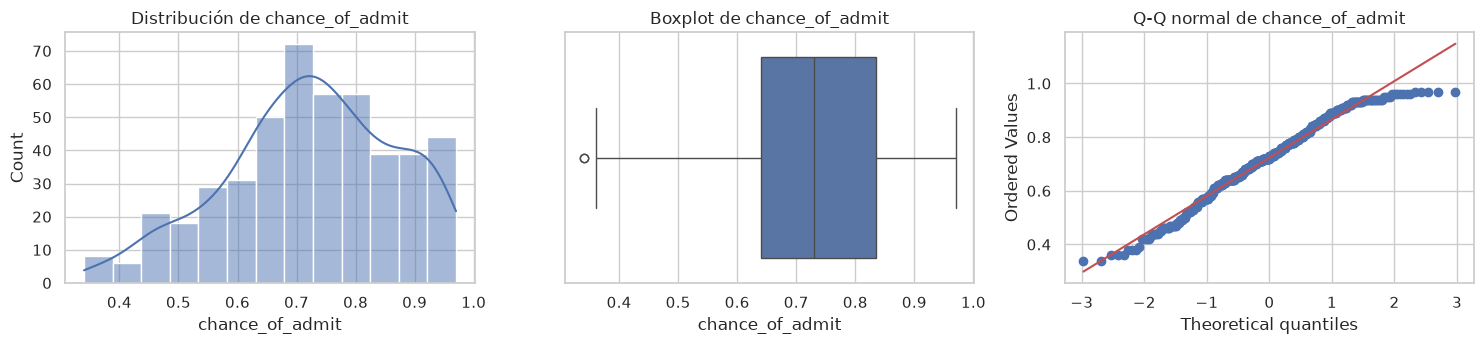

In [6]:
ALFA = 0.05


def perfil_numerica(df: pd.DataFrame, columna: str) -> pd.Series:
    """Estadísticos completos, prueba de normalidad y gráficos de una variable numérica."""
    serie = df[columna].astype(float).dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior, limite_superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = serie[(serie < limite_inferior) | (serie > limite_superior)]

    resumen = pd.Series(
        {
            "n": len(serie),
            "media": serie.mean(),
            "mediana": serie.median(),
            "moda": serie.mode().iloc[0],
            "minimo": serie.min(),
            "maximo": serie.max(),
            "rango": serie.max() - serie.min(),
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "varianza": serie.var(),
            "desv_estandar": serie.std(),
            "coef_variacion_%": 100 * serie.std() / serie.mean(),
            "skewness": serie.skew(),
            "kurtosis_exceso": serie.kurt(),
            "n_atipicos_iqr": len(atipicos),
        }
    ).round(3)

    p_shapiro = stats.shapiro(serie).pvalue
    p_dagostino = stats.normaltest(serie).pvalue
    veredicto = (
        "no se rechaza normalidad"
        if min(p_shapiro, p_dagostino) > ALFA
        else "se rechaza normalidad"
    )
    print(resumen.to_string())
    print(f"\nlimites IQR 1.5x : [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"shapiro-wilk p   : {p_shapiro:.2e}")
    print(f"d'agostino k2 p  : {p_dagostino:.2e}   -> {veredicto} (alfa={ALFA})")

    _, axes = plt.subplots(1, 3, figsize=(15, 3.6))
    sns.histplot(serie, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribución de {columna}")
    sns.boxplot(x=serie, ax=axes[1])
    axes[1].set_title(f"Boxplot de {columna}")
    stats.probplot(serie, dist="norm", plot=axes[2])
    axes[2].set_title(f"Q-Q normal de {columna}")
    plt.tight_layout()
    plt.show()
    return resumen


_ = perfil_numerica(df, "chance_of_admit")

**Lectura:** media 0.724, mediana 0.730 y moda 0.64, con desviación estándar 0.144
sobre un rango observado de 0.34 a 0.97. El coeficiente de variación (19.9 %) es el
más alto del dataset, lo que es buena noticia: el target **tiene variabilidad que
explicar**, no es casi constante.

*Skewness* −0.35 (cola ligeramente más larga hacia la izquierda) y *kurtosis* de
exceso −0.41 (más plana que una gaussiana, sin pico marcado). Las dos pruebas de
normalidad rechazan la hipótesis de gaussianidad, pero por poco margen y por la forma
achatada, no por asimetría fuerte: en el Q-Q los puntos siguen la diagonal salvo en
los extremos. **No hace falta transformarla** (log o Box-Cox) para modelarla.

Los 2 valores fuera del rango intercuartílico son aspirantes con probabilidad 0.34, el
mínimo observado: son la cola real de la distribución, no errores de captura, y no se
deben eliminar.

## 🔢 Variables numéricas explicativas

`gre_score`, `toefl_score`, `sop`, `lor` y `cgpa`. Se aplica a cada una el mismo
perfil que al target, para poder compararlas entre sí.

### `gre_score`

Puntaje del examen GRE. Entero, acotado por el dominio documentado [0, 340].

n                   460.000
media               316.459
mediana             316.500
moda                312.000
minimo              290.000
maximo              340.000
rango                50.000
q1                  308.000
q3                  325.000
iqr                  17.000
varianza            134.854
desv_estandar        11.613
coef_variacion_%      3.670
skewness             -0.033
kurtosis_exceso      -0.746
n_atipicos_iqr        0.000

limites IQR 1.5x : [282.50, 350.50]
shapiro-wilk p   : 8.41e-05
d'agostino k2 p  : 7.08e-07   -> se rechaza normalidad (alfa=0.05)


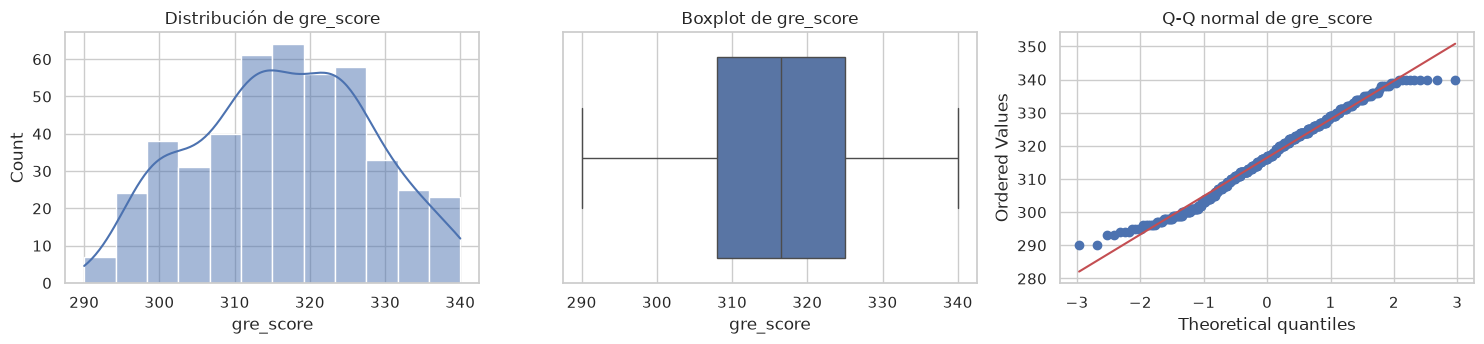

In [7]:
_ = perfil_numerica(df, "gre_score")

Media 316.5 y mediana 316.5, moda 312, con valores observados entre 290 y 340 — es
decir, el dominio documentado llega a 0 pero **nadie en la muestra baja de 290**. La
asimetría es prácticamente nula (−0.03) y la kurtosis −0.75: una distribución
simétrica pero claramente **más plana que una gaussiana** (las pruebas rechazan
normalidad por eso, no por sesgo). Sin valores atípicos según IQR. Coeficiente de
variación 3.7 %: poca dispersión relativa, típico de un examen estandarizado.

### `toefl_score`

Puntaje del examen TOEFL de inglés. Entero, acotado [0, 120].

n                   452.000
media               107.465
mediana             107.000
moda                110.000
minimo               92.000
maximo              120.000
rango                28.000
q1                  103.000
q3                  112.000
iqr                   9.000
varianza             37.566
desv_estandar         6.129
coef_variacion_%      5.703
skewness              0.013
kurtosis_exceso      -0.606
n_atipicos_iqr        0.000

limites IQR 1.5x : [89.50, 125.50]
shapiro-wilk p   : 4.70e-04
d'agostino k2 p  : 8.31e-04   -> se rechaza normalidad (alfa=0.05)


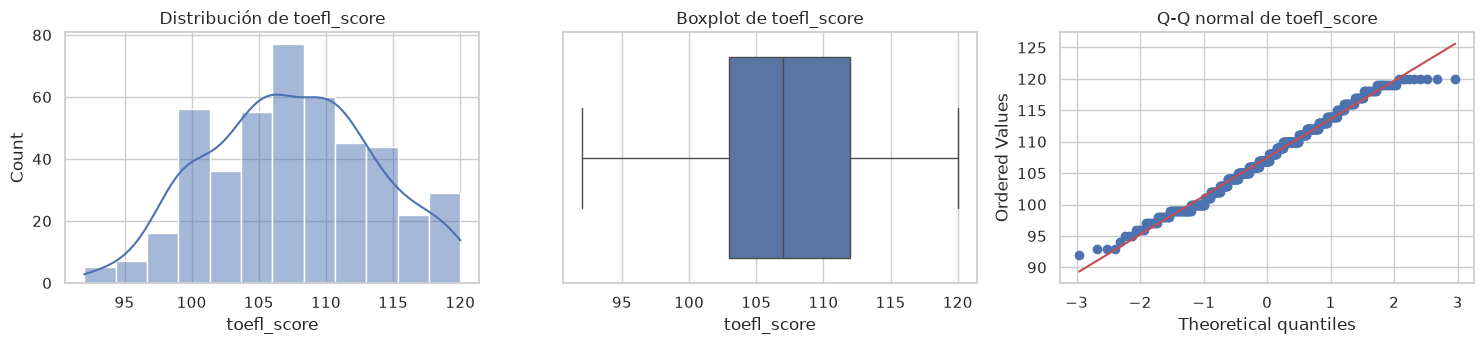

In [8]:
_ = perfil_numerica(df, "toefl_score")

Media 107.5, mediana 107, moda 110, rango observado 92-120. *Skewness* 0.013
(prácticamente simétrica) y kurtosis −0.61, otra vez más plana que la normal. Sin
atípicos. Se comporta casi igual que `gre_score`, lo que ya anticipa que ambas miden
algo muy parecido (se confirma en `03.2`: r = 0.85).

### `sop` (*statement of purpose*)

Fuerza de la carta de intención, en pasos de 0.5 sobre una escala [1, 5]. Aunque el
tipo almacenado es flotante, **conceptualmente es una escala ordinal de 9 niveles**.

n                   455.000
media                 3.407
mediana               3.500
moda                  3.500
minimo                1.000
maximo                5.000
rango                 4.000
q1                    2.500
q3                    4.000
iqr                   1.500
varianza              1.022
desv_estandar         1.011
coef_variacion_%     29.669
skewness             -0.290
kurtosis_exceso      -0.694
n_atipicos_iqr        0.000

limites IQR 1.5x : [0.25, 6.25]
shapiro-wilk p   : 1.12e-10
d'agostino k2 p  : 7.75e-07   -> se rechaza normalidad (alfa=0.05)


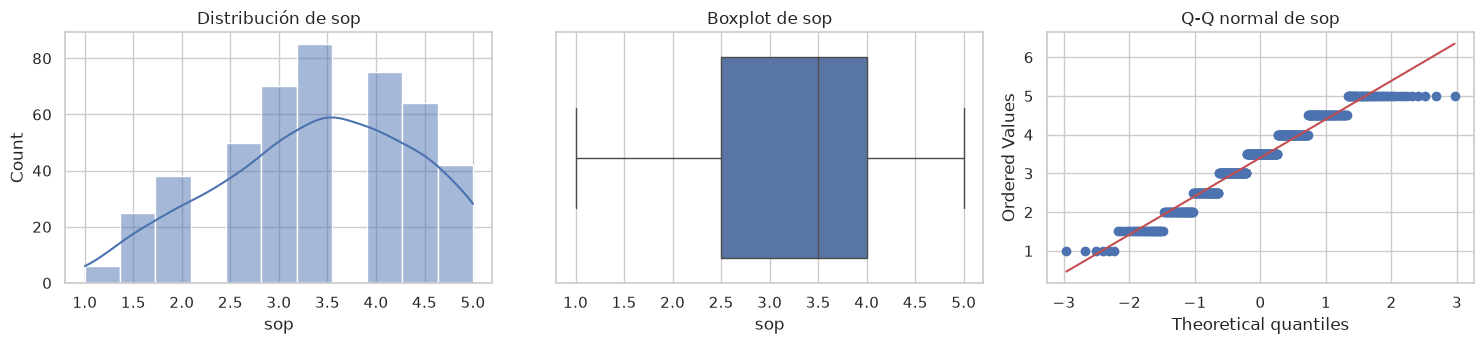

In [9]:
_ = perfil_numerica(df, "sop")

Media 3.41, mediana y moda 3.5. Es la variable explicativa con más asimetría del grupo
(*skewness* −0.29): hay más densidad en los valores altos que en los bajos, lo
esperable en una autoevaluación. Su coeficiente de variación (29.7 %) es el mayor de
todos los predictores.

El histograma muestra barras separadas y no una curva continua: es la resolución del
instrumento (9 valores posibles), no ruido. Por eso la prueba de normalidad la rechaza
con un p muy pequeño — **una variable discreta nunca va a pasar una prueba de
normalidad**, y no tiene por qué hacerlo. Sin atípicos según IQR.

### `lor` (*letter of recommendation*)

Fuerza de las cartas de recomendación. Misma escala y mismos pasos que `sop`, pero
evaluada por terceros y no por el propio aspirante.

n                   463.000
media                 3.467
mediana               3.500
moda                  3.000
minimo                1.000
maximo                5.000
rango                 4.000
q1                    3.000
q3                    4.000
iqr                   1.000
varianza              0.806
desv_estandar         0.898
coef_variacion_%     25.894
skewness             -0.073
kurtosis_exceso      -0.695
n_atipicos_iqr        1.000

limites IQR 1.5x : [1.50, 5.50]
shapiro-wilk p   : 1.48e-10
d'agostino k2 p  : 1.13e-05   -> se rechaza normalidad (alfa=0.05)


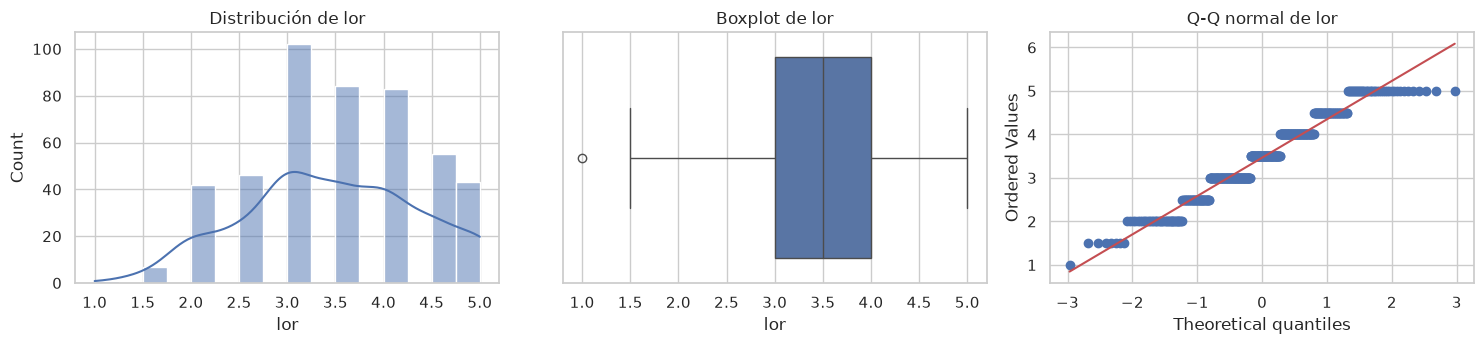

In [10]:
_ = perfil_numerica(df, "lor")

Media 3.47, mediana 3.5, moda 3.0. Casi simétrica (*skewness* −0.07) y algo menos
dispersa que `sop` (IQR de 1.0 frente a 1.5). Tiene **1 valor atípico según IQR**: el
mínimo, 1.0 — un único aspirante con una carta calificada muy por debajo del resto. Es
un caso aislado dentro del dominio válido, no un patrón ni un error.

### `cgpa`

Promedio acumulado del pregrado, continuo, acotado [0, 10]. Es la única variable
explicativa verdaderamente continua del dataset (168 valores distintos en 469 filas).

n                   469.000
media                 8.593
mediana               8.600
moda                  8.000
minimo                6.800
maximo                9.920
rango                 3.120
q1                    8.170
q3                    9.060
iqr                   0.890
varianza              0.354
desv_estandar         0.595
coef_variacion_%      6.922
skewness             -0.064
kurtosis_exceso      -0.473
n_atipicos_iqr        1.000

limites IQR 1.5x : [6.83, 10.40]
shapiro-wilk p   : 3.95e-02
d'agostino k2 p  : 2.30e-02   -> se rechaza normalidad (alfa=0.05)


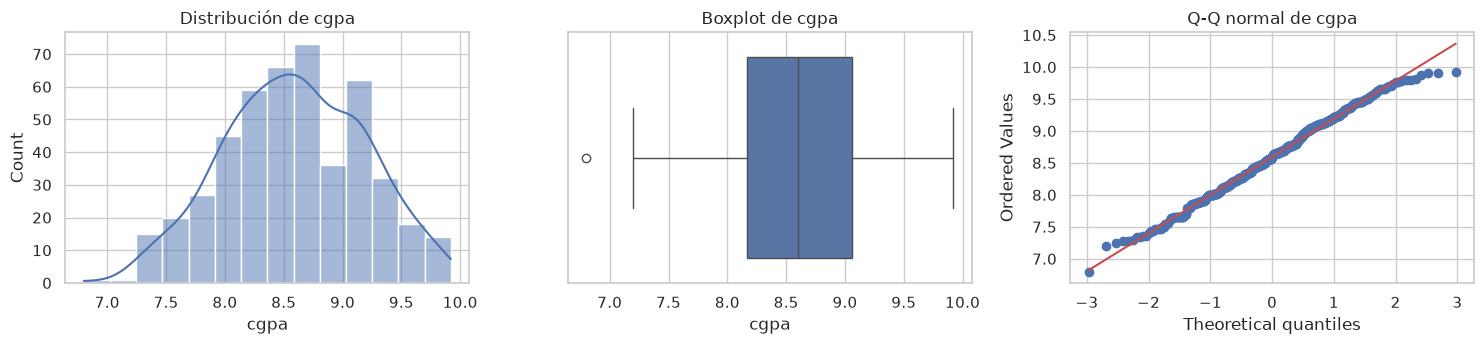

In [11]:
_ = perfil_numerica(df, "cgpa")

Media 8.59 sobre 10: el conjunto está formado por aspirantes con promedios altos, es
decir, **la muestra ya viene filtrada por un perfil competitivo** y no representa a la
población general de estudiantes. Es la limitación más importante para generalizar
cualquier modelo entrenado con estos datos.

*Skewness* −0.06 y kurtosis −0.47: es la distribución más cercana a una gaussiana del
dataset — de hecho es la única cuya prueba de Shapiro-Wilk queda al borde del umbral
(p = 0.04). Tiene 1 atípico bajo según IQR (6.8, el mínimo observado).

## 🏷️ Variables categóricas

`university_rating` (categórica **ordinal**) y `research` (booleana). Para estas no
aplican media ni desviación estándar: la descripción correcta es la tabla de
frecuencias, la moda y el balance entre niveles.

                     n     %
university_rating           
1                   28   6.0
2                  121  26.0
3                  158  34.0
4                   83  17.8
5                   75  16.1
NaN                  6   NaN


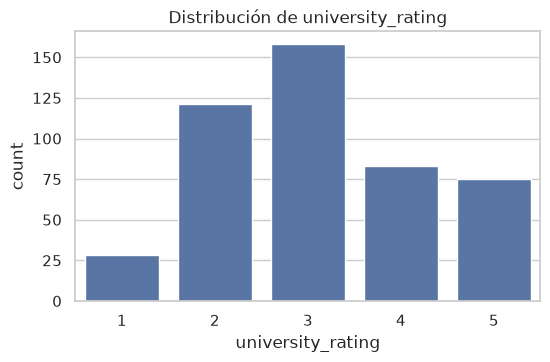

In [12]:
conteo_rating = df["university_rating"].value_counts(dropna=False).sort_index()
frecuencia_rating = (df["university_rating"].value_counts(normalize=True).sort_index() * 100).round(
    1
)
print(pd.DataFrame({"n": conteo_rating, "%": frecuencia_rating}).to_string())

_, ax = plt.subplots(figsize=(6, 3.5))
sns.countplot(
    x=df["university_rating"], order=sorted(df["university_rating"].dropna().unique()), ax=ax
)
ax.set_title("Distribución de university_rating")
plt.show()

Moda clara en el nivel 3 (158 de 471 filas, 34.0 % de los no nulos) y caída hacia los
extremos: 28 aspirantes en el nivel 1 y 75 en el nivel 5. La distribución es unimodal y
ligeramente sesgada hacia los niveles bajos-medios. 6 valores nulos (1.27 %).

Los niveles extremos, sobre todo el 1 (n = 28), tienen **pocos datos**: cualquier
estimación por grupo en ese nivel llevará mucha incertidumbre, algo que hay que tener
presente al leer los promedios por categoría de `03.2` y `03.3`.

research
True     237
False    205
<NA>      29

Balance (True / total no nulo): 53.6%


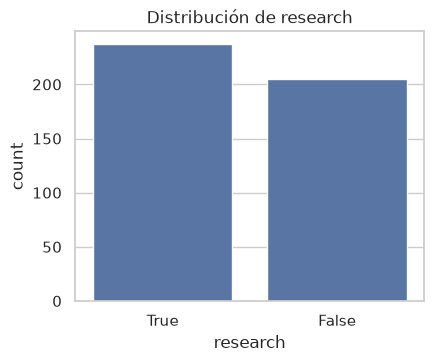

In [13]:
conteo_research = df["research"].value_counts(dropna=False)
print(conteo_research.to_string())
print(f"\nBalance (True / total no nulo): {100 * df['research'].mean():.1f}%")

_, ax = plt.subplots(figsize=(4.5, 3.5))
sns.countplot(x=df["research"].astype("string"), ax=ax)
ax.set_title("Distribución de research")
plt.show()

`research` está razonablemente balanceada: 237 aspirantes con experiencia en
investigación frente a 205 sin ella (53.6 % / 46.4 %), así que no hay problema de
categoría minoritaria. Es, eso sí, **la columna con más nulos del dataset**: 29
(6.16 %).

Al ser binaria no admite imputación por la media (0.536 no es un valor válido); la
estrategia tendrá que ser la moda, un modelo, o un modelo que acepte nulos de forma
nativa. Esa decisión corresponde a `4-feat_eng`.

## 🔁 Duplicados exactos: filas y columnas

En `2-exploration` se eliminaron 152 filas duplicadas. Se vuelve a comprobar aquí para
que el notebook sea autocontenido, y se añade la comprobación que falta: si alguna
**columna** es copia exacta de otra (redundancia perfecta, que rompería un modelo
lineal).

In [14]:
n_duplicados_fila = int(df.duplicated().sum())
columnas_identicas = [
    (a, b) for i, a in enumerate(df.columns) for b in df.columns[i + 1 :] if df[a].equals(df[b])
]

print(f"Filas duplicadas exactas   : {n_duplicados_fila}")
print(f"Pares de columnas idénticas: {columnas_identicas}")
print(f"Filas con algún nulo       : {int(df.isna().any(axis=1).sum())} de {len(df)}")

Filas duplicadas exactas   : 0
Pares de columnas idénticas: []
Filas con algún nulo       : 71 de 471


0 filas duplicadas y ninguna columna es copia exacta de otra.

**Tipos de ruido presentes en el dataset**, que es lo que pide caracterizar esta etapa:

| Tipo de ruido | ¿Presente? | Dónde |
|---|---|---|
| Redondeo / resolución del instrumento | **Sí** | `sop` y `lor` (pasos de 0.5), `university_rating` (5 niveles) |
| Valores atípicos dentro del dominio válido | **Sí, aislados** | `lor` (1), `cgpa` (1), `chance_of_admit` (2) |
| Errores de captura / fuera de dominio | No | ninguna columna sale de su rango documentado |
| Ruido estocástico tipo sensor | No aplica | los datos son puntajes y evaluaciones, no mediciones físicas |
| Duplicación de registros | Ya corregido | 152 filas eliminadas en `2-exploration` |

Ninguno de los atípicos detectados justifica eliminar filas: son 4 casos en total,
todos dentro del dominio válido y coherentes entre sí (un aspirante con `cgpa` bajo y
`chance_of_admit` bajo no es un error, es el extremo real de la muestra).

## ✅ Reglas de validación de datos

Reglas derivadas de este análisis, para aplicar en cualquier carga futura del dataset.
Se separan en **duras** (violarlas significa que el dato está mal y debe fallar la
carga) y **blandas** (violarlas es sospechoso y merece una alerta, porque se sale de lo
observado aunque siga siendo válido en teoría).

| Columna | Regla dura | Regla blanda (alerta) |
|---|---|---|
| `gre_score` | entero, 0 ≤ x ≤ 340, nulos permitidos | fuera de [290, 340] |
| `toefl_score` | entero, 0 ≤ x ≤ 120, nulos permitidos | fuera de [92, 120] |
| `university_rating` | categórica ordinal ∈ {1,2,3,4,5}, nulos permitidos | ninguna categoría nueva |
| `sop` | flotante, 1 ≤ x ≤ 5, múltiplo de 0.5, nulos permitidos | — |
| `lor` | flotante, 1 ≤ x ≤ 5, múltiplo de 0.5, nulos permitidos | — |
| `cgpa` | flotante, 0 ≤ x ≤ 10, nulos permitidos | fuera de [6.8, 10] |
| `research` | booleana, nulos permitidos | proporción de `True` fuera de [40 %, 65 %] |
| `chance_of_admit` | flotante, 0 ≤ x ≤ 1, **sin nulos** (es el target) | — |
| (dataset) | 0 filas duplicadas exactas; ninguna columna idéntica a otra | > 10 % de nulos en cualquier columna |

La celda siguiente implementa estas reglas como una función reutilizable y la ejecuta
sobre el dataset actual: es el germen del contrato de datos que puede formalizarse con
`pandera` en el pipeline.

In [15]:
REGLAS_DURAS = {
    "gre_score": (0, 340),
    "toefl_score": (0, 120),
    "sop": (1, 5),
    "lor": (1, 5),
    "cgpa": (0, 10),
    "chance_of_admit": (0, 1),
}
CATEGORIAS_RATING = {1, 2, 3, 4, 5}
MAX_NULOS_ACEPTABLE = 0.10


def validar(df: pd.DataFrame) -> list[str]:
    """Aplica las reglas de validación y devuelve la lista de incumplimientos."""
    fallos = []
    for columna, (minimo, maximo) in REGLAS_DURAS.items():
        serie = df[columna].astype(float).dropna()
        fuera = serie[(serie < minimo) | (serie > maximo)]
        if len(fuera):
            fallos.append(f"{columna}: {len(fuera)} valores fuera de [{minimo}, {maximo}]")
    if not set(df["university_rating"].dropna().astype(int)) <= CATEGORIAS_RATING:
        fallos.append("university_rating: categorias fuera de {1,2,3,4,5}")
    if df[TARGET].isna().any():
        fallos.append(f"{TARGET}: el target no admite nulos")
    if df.duplicated().any():
        fallos.append(f"dataset: {int(df.duplicated().sum())} filas duplicadas exactas")
    excedidas = df.columns[df.isna().mean() > MAX_NULOS_ACEPTABLE].tolist()
    if excedidas:
        fallos.append(
            f"dataset: columnas con mas de {MAX_NULOS_ACEPTABLE:.0%} de nulos: {excedidas}"
        )
    return fallos


incumplimientos = validar(df)
print(
    "\n".join(incumplimientos)
    if incumplimientos
    else "El dataset cumple todas las reglas de validacion."
)

El dataset cumple todas las reglas de validacion.


## 📊 Analysis of Results and Conclusions

**Estado del dataset:** 471 filas x 8 columnas, sin duplicados de fila ni de columna,
con nulos repartidos entre el 0 % (`chance_of_admit`) y el 6.16 % (`research`).

**Resumen estadístico de las variables numéricas:**

| Variable | Media | Mediana | Moda | Desv. est. | CV | Skew | Kurtosis | Atípicos IQR |
|---|---|---|---|---|---|---|---|---|
| `gre_score` | 316.46 | 316.5 | 312 | 11.61 | 3.7 % | −0.03 | −0.75 | 0 |
| `toefl_score` | 107.47 | 107.0 | 110 | 6.13 | 5.7 % | 0.01 | −0.61 | 0 |
| `sop` | 3.41 | 3.5 | 3.5 | 1.01 | 29.7 % | −0.29 | −0.69 | 0 |
| `lor` | 3.47 | 3.5 | 3.0 | 0.90 | 25.9 % | −0.07 | −0.70 | 1 |
| `cgpa` | 8.59 | 8.60 | 8.0 | 0.60 | 6.9 % | −0.06 | −0.47 | 1 |
| `chance_of_admit` | 0.724 | 0.730 | 0.64 | 0.144 | 19.9 % | −0.35 | −0.41 | 2 |

**Hallazgos principales:**

- **Tipo de distribución:** ninguna variable pasa una prueba formal de normalidad, pero
  por dos razones distintas. `sop`, `lor` y `university_rating` son **escalas ordinales
  discretas** y no pueden ser gaussianas por construcción. `gre_score`, `toefl_score`,
  `cgpa` y el target son simétricas (|skew| < 0.35) pero **platicúrticas** (kurtosis de
  exceso entre −0.4 y −0.75): más planas y anchas que una campana, más cercanas a una
  meseta. Ninguna es logarítmica ni exponencial, así que **no se justifica ninguna
  transformación de forma** (log, raíz, Box-Cox) antes de modelar.
- **Escalas muy distintas:** `gre_score` vive en el orden de las centenas y `sop`/`lor`
  entre 1 y 5. Cualquier modelo basado en distancias o con regularización necesita
  estandarización previa.
- **Sesgo de selección de la muestra:** con `cgpa` medio de 8.59/10 y `gre_score` mínimo
  de 290, el dataset representa aspirantes competitivos, no la población general. Un
  modelo entrenado aquí **no se puede extrapolar** a perfiles con promedios bajos.
- **`research`** es la columna más incompleta (6.16 %) y la única binaria: no admite
  imputación por la media.
- **El target no necesita transformación** y tiene variabilidad suficiente (CV 19.9 %)
  para que el problema tenga sentido.

**Lo que queda abierto** (y se retoma en los siguientes notebooks): las relaciones
entre atributos (`03.2`), las interacciones entre tres o más variables y el modelo
heurístico viable (`03.3`).

## 💡 Proposals and Ideas

- Formalizar la tabla de reglas de validación como un esquema `pandera` dentro del
  pipeline, usando la función `validar()` de este notebook como punto de partida, para
  que cualquier carga futura falle temprano y de forma explícita.
- Decidir la estrategia de imputación por columna en `4-feat_eng` y no antes: mediana
  para las numéricas, moda o modelo para `research`. Imputar en esta etapa habría
  sesgado todos los estadísticos de arriba.
- Documentar el sesgo de selección de la muestra como una limitación explícita del
  modelo final, no como un detalle técnico: condiciona a qué usuarios se les puede
  mostrar la predicción.

## 📖 References

- Análisis univariable, Jose R. Zapata:
  <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/>
- `scipy.stats.shapiro` y `normaltest`: <https://docs.scipy.org/doc/scipy/reference/stats.html>
- Interpretación de *skewness* y *kurtosis*:
  <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.kurt.html>